# 05 · Correlations and conclusions

Rank simple associations with survival. Pearson correlation with a binary target is also called point-biserial correlation; it does not establish causation or model accuracy.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data = pd.read_csv(root / "data" / "cleaned.csv")
plt.rcParams.update({"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False})

In [2]:
encoded = data.assign(Female=data["Sex"].map({"male": 0, "female": 1}))
names = {"PassengerId": "Passenger ID", "Pclass": "Passenger class", "Age": "Age",
         "SibSp": "Siblings / spouses", "Parch": "Parents / children", "Fare": "Fare", "Female": "Gender (female=1)"}
correlation = encoded[list(names) + ["Survived"]].corr()["Survived"].drop("Survived").rename(index=names).sort_values()
print(correlation.round(4).to_string())

Passenger class      -0.3385
Age                  -0.0649
Siblings / spouses   -0.0353
Passenger ID         -0.0050
Parents / children    0.0816
Fare                  0.2573
Gender (female=1)     0.5434


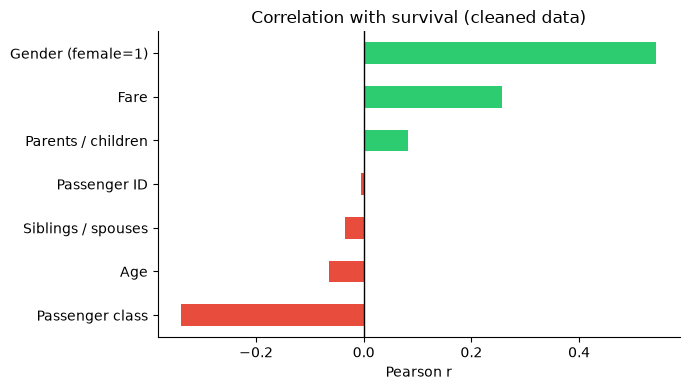

In [3]:
colors = ["#2ecc71" if value >= 0 else "#e74c3c" for value in correlation]
correlation.plot.barh(color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation with survival (cleaned data)")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

## Top 3 factors, ranked by absolute correlation

1. **Gender (+0.5434):** being female has the strongest linear association with survival in this sample.
2. **Passenger class (−0.3385):** a higher class number means lower travel class and is associated with lower survival.
3. **Fare (+0.2573):** higher fares are associated with survival and overlap with passenger class.

**Surprising finding:** age has a weak linear association (−0.0649) after median imputation. This does not mean age never mattered: linear correlation and averages can conceal subgroup patterns.

**Limitations:** Cabin was dropped because 77.10% is missing. Median age imputation reduces variation. Passenger ID is shown for completeness, not interpretation. Text categories are excluded from this numeric correlation chart except for binary-encoded Sex. These are descriptive associations from 891 records, not independent causal effects or a trained prediction model.